# Iris Plant Classification 🌸

This project applies Machine Learning techniques to classify Iris flowers
into three species: Setosa, Versicolor, and Virginica using the Iris dataset.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import seaborn as sn
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import joblib

## Objective

The goal of this project is to build a classification model that can correctly
identify the species of an Iris flower based on its physical measurements.


In [2]:
petals = load_iris(as_frame = True)
dir(petals)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

## Dataset Description

The Iris dataset contains 150 samples with four numerical features:
- Sepal length
- Sepal width
- Petal length
- Petal width

The target variable represents three Iris species.


In [3]:
petals.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

## Feature and Target Selection

The dataset is divided into:
- Features (X): Flower measurements
- Target (y): Species labels


In [4]:
X = petals.data
Y = petals.target


## Train-Test Split

The dataset is split into training and testing sets to evaluate
model performance on unseen data.


In [5]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 67)

## Feature Scaling

Feature scaling is applied using StandardScaler to ensure that all
features contribute equally to the model.


In [6]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

Logistic Regression is used for multi-class classification because
it performs well on linearly separable datasets like Iris.


In [7]:

classification_model = LogisticRegression()
classification_model.fit(X_train_scaled,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Evaluation

The trained model is evaluated using predictions and confusion matrix


Text(58.222222222222214, 0.5, 'Predicted')

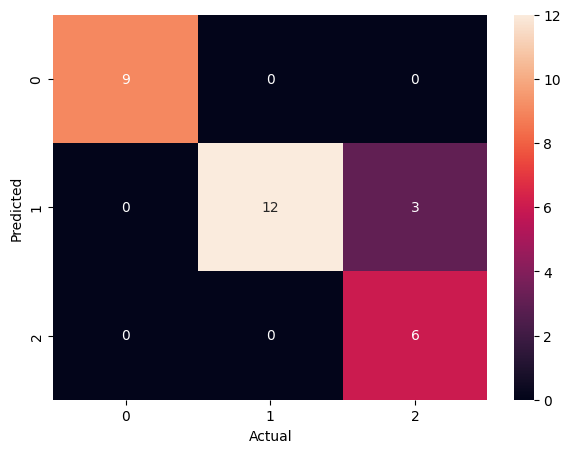

In [8]:
Y_pred = classification_model.predict(X_test_scaled)

conf_mat = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize = (7,5))
sn.heatmap(conf_mat, annot = True)
plt.xlabel('Actual')
plt.ylabel('Predicted')



In [9]:
classification_model.score(X_test_scaled, Y_test)

0.9

In [10]:
petals.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [11]:
actual_names = [petals.target_names[i]  for i in Y_test]
predicted_names = [petals.target_names[i] for i in Y_pred]
result_df = pd.DataFrame({
    "Actual Species " : actual_names,
    "Predicted Species ": predicted_names
})
result_df.head(10)

,Actual Species,Predicted Species
0,setosa,setosa
1,setosa,setosa
2,versicolor,versicolor
3,setosa,setosa
4,versicolor,versicolor
5,setosa,setosa
6,setosa,setosa
7,versicolor,versicolor
8,versicolor,versicolor
9,versicolor,versicolor


## Results and Observations

The model predictions were compared with the actual test labels using
a confusion matrix.

- The model correctly classifies most samples
- Iris Setosa is classified perfectly
- Some confusion is observed between Versicolor and Virginica

This indicates that Logistic Regression performs well on the Iris dataset.


In [12]:
joblib.dump(classification_model, 'iris_model.joblib')
joblib.dump(scaler , 'scaler_iris_model.joblib')

['scaler_iris_model.joblib']

## Conclusion

In this project, a Logistic Regression model was trained to classify Iris
flower species using four numerical features. After preprocessing and
evaluation, the model achieved high accuracy and produced reliable
human-readable predictions.
